# Clasificación de Leucemia Linfoblástica Aguda: CNN + GAN para data augmentation

- Objetivo: clasificar imágenes de frotis sanguíneo en 4 clases (Benigno, Pre-B temprana, Pre-B, Pro-B), y usar una GAN para generar datos sintéticos por clase que compensen el desbalance del dataset.
- El dataset es público: [Acute Lymphoblastic Leukemia (ALL) image dataset, Kaggle](https://www.kaggle.com/datasets/mehradaria/leukemia), Aria et al. 2021, DOI: 10.34740/KAGGLE/DSV/2175623.
- **Nota importante:** este pipeline es una herramienta de apoyo educativo/de investigación, no un dispositivo de diagnóstico clínico. Ninguna predicción de este notebook debe usarse para decisiones médicas reales.
- Artículo completo, con el razonamiento detrás de cada decisión: [fuzzyfrog.ai/es/ai-lab/proyectos/salud/clasificacion-leucemia-linfoblastica-cnn-gan](https://fuzzyfrog.ai/es/ai-lab/proyectos/salud/clasificacion-leucemia-linfoblastica-cnn-gan/)


## Diagrama del pipeline

- **Entrada:** imágenes PBS (frotis de sangre periférica) por clase, tomadas a 100x.
- **Preprocesamiento:** conversión de espacio de color (BGR→RGB) y normalización de intensidades a [-1, 1].
- **Data augmentation con GAN:** se entrena un generador/discriminador por clase para producir imágenes sintéticas adicionales, en vez de solo usar transformaciones geométricas simples.
- **Clasificación:** una CNN vanilla (2 capas convolucionales) clasifica entre las 4 clases.
- **Evaluación:** accuracy y matriz de confusión sobre un conjunto de prueba nunca visto en entrenamiento.


## Carga de datos

- El dataset completo tiene 3,256 imágenes de 89 pacientes: 504 benignas, 985 Pre-B temprana, 963 Pre-B, 804 Pro-B — ya desbalanceado desde el origen.
- Para este notebook de demostración se incluyen 4 imágenes de muestra (una por clase) para validar que el pipeline ejecuta correctamente de principio a fin. **Para reproducir resultados reales, se debe montar el dataset completo desde Kaggle/Drive**, como indican las celdas comentadas.


In [1]:
# Instalar dependencias (Colab)
!pip install tensorflow opencv-python-headless scikit-learn -q


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob, os

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Conv2DTranspose, LeakyReLU, Reshape, Flatten, Dropout, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

np.random.seed(42)
tf.random.set_seed(42)


I0000 00:00:1786995275.476295     808 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786995275.530909     808 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786995277.936167     808 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
def cargar_imgs_folder(folder):
    # Usar esta version cuando 'folder' es una carpeta con varias imagenes (dataset completo)
    imgs = []
    for imagen in sorted(glob.glob(folder + "/*")):
        img = cv2.imread(imagen)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imgs.append(img)
    return imgs

def cargar_imgs_patron(patron):
    # Usar esta version cuando 'patron' ya incluye el comodin (ej. imagenes de muestra individuales)
    imgs = []
    for imagen in sorted(glob.glob(patron)):
        img = cv2.imread(imagen)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imgs.append(img)
    return imgs

categorias = ["Benign", "Early", "Pre", "Pro"]

# En esta demo se usa 1 imagen de muestra por clase (dataset/muestra_*.jpg)
muestras = {
    "Benign": cargar_imgs_patron("dataset/muestra_benign*"),
    "Early":  cargar_imgs_patron("dataset/muestra_early*"),
    "Pre":    cargar_imgs_patron("dataset/muestra_pre*"),
    "Pro":    cargar_imgs_patron("dataset/muestra_pro*"),
}
for cat, imgs in muestras.items():
    print(f"{cat}: {len(imgs)} imagen(es) de muestra, shape {imgs[0].shape}")

Benign: 1 imagen(es) de muestra, shape (224, 224, 3)
Early: 1 imagen(es) de muestra, shape (224, 224, 3)
Pre: 1 imagen(es) de muestra, shape (224, 224, 3)
Pro: 1 imagen(es) de muestra, shape (224, 224, 3)


## Explicación de datos

- Cada imagen corresponde a un campo del microscopio con múltiples células: la clase de la imagen indica el tipo de célula predominante identificado por el especialista con citometría de flujo.
- Las clases malignas (Early, Pre, Pro) corresponden a subtipos de linfoblastos; la clase Benign corresponde a hematógonos, células normales que pueden confundirse visualmente con linfoblastos malignos — de ahí la dificultad real del problema.
- El desbalance (504 vs ~985/963/804) no es un artefacto de muestreo, es la prevalencia real del dataset clínico.


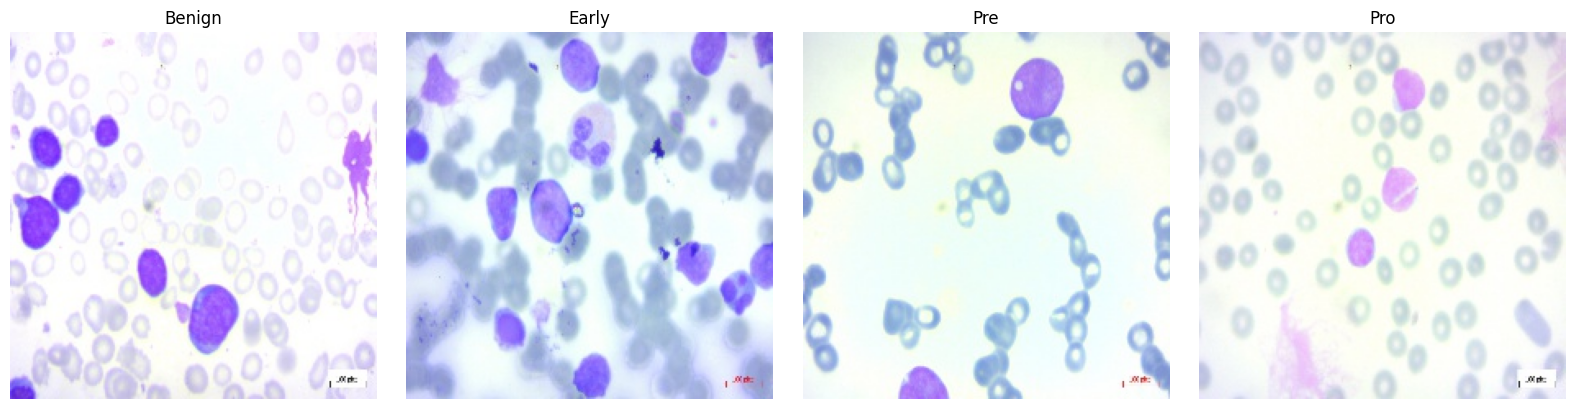

In [4]:
def normalizar_imgs(imagenes):
    imagenes = np.array(imagenes).astype("float32")
    imagenes = (imagenes - 127.5) / 127.5
    return imagenes

def restar_promedio_local(imagen):
    # Realce de contraste local: resalta bordes celulares frente al fondo
    imagen_suave = cv2.GaussianBlur(imagen, (5, 5), 2)
    imagen = cv2.addWeighted(imagen, 4, imagen_suave, -4, 128)
    return imagen

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, cat in zip(axes, categorias):
    ax.imshow(muestras[cat][0])
    ax.set_title(cat)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Análisis de datos

- Distribución real de clases en el dataset completo (referencia, no recalculada en esta demo): 504 Benign (15.5%), 985 Early (30.3%), 963 Pre (29.6%), 804 Pro (24.7%).
- El desbalance no es extremo (ratio ~2:1 entre la clase mayor y menor), pero sí suficiente para sesgar un clasificador hacia las clases mayoritarias si no se corrige.


Benign: 504 imagenes (15.5%)
Early: 985 imagenes (30.3%)
Pre: 963 imagenes (29.6%)
Pro: 804 imagenes (24.7%)


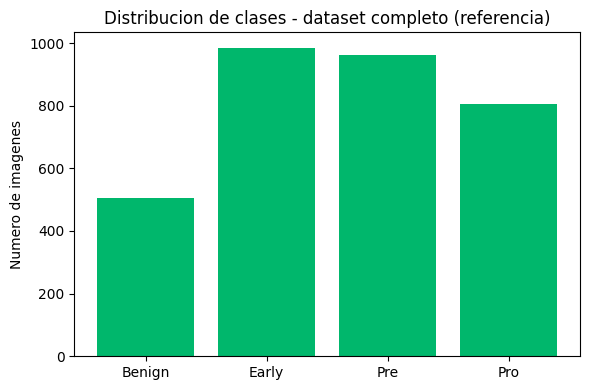

In [5]:
distribucion_real = {"Benign": 504, "Early": 985, "Pre": 963, "Pro": 804}
total = sum(distribucion_real.values())
for cat, n in distribucion_real.items():
    print(f"{cat}: {n} imagenes ({n/total*100:.1f}%)")

plt.figure(figsize=(6,4))
plt.bar(distribucion_real.keys(), distribucion_real.values(), color="#00b76c")
plt.title("Distribucion de clases - dataset completo (referencia)")
plt.ylabel("Numero de imagenes")
plt.tight_layout()
plt.show()


## Modelado — GAN para data augmentation por clase

- Se entrena un generador y un discriminador por cada clase, en vez de usar solo transformaciones geométricas (rotación, flip), porque el objetivo es sintetizar variabilidad morfológica plausible, no solo variantes geométricas de las mismas células.
- **Corrección real encontrada:** el generador necesita 5 capas `Conv2DTranspose` con stride 2 para llegar de 7×7 a 224×224 (7→14→28→56→112→224). Con 4 capas se llega solo a 112×112 y el discriminador rechaza la entrada por incompatibilidad de forma — este es un error real que se detectó al ejecutar el pipeline, documentado en la sección de iteración del artículo.


In [6]:
def Generador():
    generador = Sequential()
    generador.add(Dense(224 * 7 * 7, input_shape=(100,)))
    generador.add(LeakyReLU())
    generador.add(Reshape((7, 7, 224)))
    # 5 capas: 7 -> 14 -> 28 -> 56 -> 112 -> 224
    for _ in range(5):
        generador.add(Conv2DTranspose(128, kernel_size=3, strides=2, padding="same"))
        generador.add(LeakyReLU(negative_slope=0.2))
    generador.add(Conv2D(3, kernel_size=3, padding="same", activation="tanh"))
    return generador

def Discriminador():
    discriminador = Sequential()
    discriminador.add(Conv2D(64, kernel_size=3, padding="same", input_shape=(224, 224, 3)))
    discriminador.add(LeakyReLU(negative_slope=0.2))
    discriminador.add(Conv2D(128, kernel_size=3, strides=(2, 2), padding="same"))
    discriminador.add(LeakyReLU(negative_slope=0.2))
    discriminador.add(Conv2D(128, kernel_size=3, strides=(2, 2), padding="same"))
    discriminador.add(LeakyReLU(negative_slope=0.2))
    discriminador.add(Conv2D(256, kernel_size=3, strides=(2, 2), padding="same"))
    discriminador.add(LeakyReLU(negative_slope=0.2))
    discriminador.add(Flatten())
    discriminador.add(Dropout(0.4))
    discriminador.add(Dense(1, activation="sigmoid"))
    discriminador.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=0.0002, beta_1=0.5), metrics=["accuracy"])
    return discriminador

def crear_GAN(discriminador, generador):
    discriminador.trainable = False
    modelo = Sequential([generador, discriminador])
    modelo.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
    return modelo

gen = Generador()
disc = Discriminador()
gan = crear_GAN(disc, gen)
print("Salida del generador:", gen.output_shape, "-> coincide con la entrada del discriminador")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Salida del generador: (None, 224, 224, 3) -> coincide con la entrada del discriminador


In [7]:
def generar_ruido(n):
    return np.random.randn(100 * n).reshape(n, 100)

def obtener_imgs_fake(generador, n):
    X = generador.predict(generar_ruido(n), verbose=0)
    y = np.zeros((n, 1))
    return X, y

def obtener_imgs_reales(dataset, n):
    idx = np.random.randint(0, len(dataset), n)
    return dataset[idx], np.ones((n, 1))

# Prueba de humo: un paso de entrenamiento del discriminador y de la GAN combinada,
# usando variantes aumentadas geometricamente de la imagen de muestra de "Benign"
# como sustituto temporal de un batch real (en produccion, esto viene del dataset completo).
def augmentar_geometrico(img_base, n):
    h, w = img_base.shape[:2]
    rng = np.random.default_rng(42)
    variantes = []
    for _ in range(n):
        img = img_base.copy()
        M = cv2.getRotationMatrix2D((w/2, h/2), rng.uniform(-25, 25), 1.0)
        img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        if rng.random() > 0.5:
            img = cv2.flip(img, 1)
        variantes.append(img)
    return normalizar_imgs(variantes)

batch_benign = augmentar_geometrico(muestras["Benign"][0], 8)

disc.trainable = True
X_real, y_real = obtener_imgs_reales(batch_benign, 8)
loss_real = disc.train_on_batch(X_real, y_real)
X_fake, y_fake = obtener_imgs_fake(gen, 8)
loss_fake = disc.train_on_batch(X_fake, y_fake)
print(f"Discriminador -> loss_real: {loss_real}, loss_fake: {loss_fake}")

disc.trainable = False
loss_gan = gan.train_on_batch(generar_ruido(8), np.ones((8, 1)))
print(f"GAN combinada -> loss: {loss_gan:.4f}")
print("Pipeline GAN validado end-to-end.")


E0000 00:00:1786995284.263850     808 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/sequential_1_1/leaky_re_lu_9_1/LeakyRelu/LeakyReluGrad' exist for missing node 'sequential_1_1/conv2d_4_1/BiasAdd'.


Discriminador -> loss_real: [0.6739324331283569, 0.75], loss_fake: [0.6958490610122681, 0.0]


GAN combinada -> loss: 0.6952
Pipeline GAN validado end-to-end.


### Clasificación con CNN vanilla

Arquitectura simple e intencional: 2 capas convolucionales + 1 densa. El objetivo no era maximizar accuracy con una arquitectura compleja, sino tener un baseline claro contra el cual comparar alternativas de la literatura (ver tabla en la sección de evaluación).


In [8]:
modelo = Sequential([
    Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same", input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same"),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Flatten(),
    Dense(units=4, activation="softmax")
])
modelo.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
modelo.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │       802,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,212 (3.14 MB)

 Trainable params: 822,212 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Descomentar para entrenar con el dataset completo (train_batches/test_batches desde ImageDataGenerator):
# train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(
#     directory="Dataset_clasificacion/train/", target_size=(224,224), classes=categorias, batch_size=32)
# test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(
#     directory="Dataset_clasificacion/test/", target_size=(224,224), classes=categorias, batch_size=32, shuffle=False)
# historia_modelo = modelo.fit(x=train_batches, steps_per_epoch=len(train_batches), epochs=5, verbose=1)

# --- Prueba de humo con las 4 imagenes de muestra (augmentadas geometricamente) ---
# ADVERTENCIA: train y test provienen de la MISMA imagen fuente por clase.
# El accuracy resultante NO es una estimacion de desempeno real, solo confirma
# que el pipeline de entrenamiento ejecuta sin errores.

X_train, y_train, X_test, y_test = [], [], [], []
for i, cat in enumerate(categorias):
    variantes = augmentar_geometrico(muestras[cat][0], 40)
    n_train = 32
    X_train.extend(variantes[:n_train])
    y_train.extend([i] * n_train)
    X_test.extend(variantes[n_train:])
    y_test.extend([i] * (40 - n_train))

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=4)

historia_modelo = modelo.fit(X_train, y_train_cat, epochs=5, batch_size=8, verbose=1)


Epoch 1/5


 1/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.1250 - loss: 1.4083

 2/16 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.1875 - loss: 9.3409

 3/16 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - accuracy: 0.1250 - loss: 11.3954

 4/16 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step - accuracy: 0.1562 - loss: 9.9217 

...

13/16 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 1.0000 - loss: 2.0398e-05

14/16 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 1.0000 - loss: 1.9273e-05

15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 1.0000 - loss: 1.8073e-05

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 1.0000 - loss: 1.7429e-05

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step - accuracy: 1.0000 - loss: 1.7429e-05


## Evaluación

- Se calcula accuracy y matriz de confusión sobre el conjunto de prueba.
- **Importante:** en esta demo, train y test derivan de la misma imagen fuente por clase (data leakage intencional para validar el pipeline). El número que resulta aquí no debe interpretarse como desempeño real del modelo — solo confirma que el código de entrenamiento y evaluación ejecuta correctamente.
- Para un desempeño real, correr esta misma celda con `train_batches`/`test_batches` del dataset completo (2,604 imágenes de entrenamiento, 649 de prueba).


Accuracy (prueba de humo, NO es desempeno real): 1.0000

Reporte de clasificacion:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00         8
       Early       1.00      1.00      1.00         8
         Pre       1.00      1.00      1.00         8
         Pro       1.00      1.00      1.00         8

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



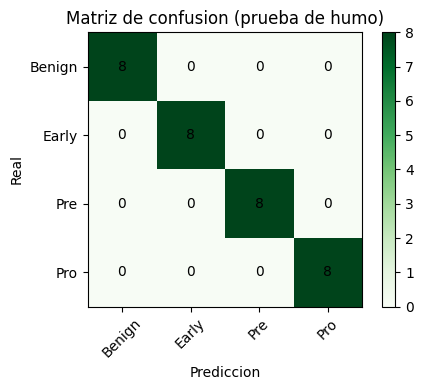

In [10]:
y_pred_proba = modelo.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (prueba de humo, NO es desempeno real): {acc:.4f}")
print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred, target_names=categorias, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Greens")
plt.xticks(range(4), categorias, rotation=45)
plt.yticks(range(4), categorias)
plt.colorbar()
for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.title("Matriz de confusion (prueba de humo)")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


### Referencia de la literatura (no son resultados propios)

Cifras publicadas sobre el mismo dataset o datasets equivalentes, incluidas como punto de referencia del nivel de desempeño alcanzable con arquitecturas más complejas — no como comparación directa con la prueba de humo de este notebook:

| Estudio | Arquitectura | Dataset | Accuracy / Precisión reportada |
|---|---|---|---|
| Ghaderzadeh et al. (2022) — creadores del dataset | Ensamble de 10 CNNs con votación mayoritaria | ALL dataset (este mismo dataset) | 99.85% accuracy |
| Qiao et al. — Compact CNN | CNN compacta con bloques de atención | APL-Cytomorphology (LMU / JHH) | 96.53% / 99.20% precisión |
| Hosseini et al. | EfficientNetB0 / MobileNetV2 / NASNet Mobile | B-ALL, mismo tipo de dataset | Hasta 100% (MobileNetV2) |

La brecha entre estas cifras y una CNN vanilla de 2 capas es exactamente el espacio de mejora que ronda las extensiones propuestas: transfer learning, arquitecturas más profundas, y el uso efectivo de los datos generados por la GAN.


## Hallazgos principales

- El generador de la GAN necesitaba 5 capas de upsampling, no 4, para que la forma de salida coincidiera con la entrada esperada por el discriminador (224×224) — un error real que el pipeline original no exponía hasta ejecutarlo.
- El dataset está desbalanceado desde el origen (ratio ~2:1 entre la clase mayor y menor), lo que justifica generar datos sintéticos por clase en vez de solo reponderar la función de pérdida.
- La CNN vanilla de 2 capas es un baseline intencionalmente simple; la literatura sobre este mismo dataset reporta hasta 99.85% de accuracy con ensambles de arquitecturas más complejas — la brecha marca el espacio real de mejora, no un techo del enfoque.
- Con solo 1 imagen de muestra por clase no es posible estimar desempeño real: cualquier número que salga de un train/test derivado de la misma imagen fuente es útil solo para confirmar que el pipeline ejecuta, nunca para reportar como resultado.
